# **KNN - UCI Breast Cancer Wisconsin**

# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns

### **Reproducibility**

In [3]:
STUDENT_ID = 42
np.random.seed(STUDENT_ID)

# **1. Load and Inspect Data**

In [4]:
# source = https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

data = pd.read_csv("C:/Users/cmanu/Downloads/archive (6)/data.csv", sep=';')  # Your file
print("Shape:", data.shape)
data.head()

Shape: (569, 1)


,"id,""diagnosis"",""radius_mean"",""texture_mean"",""perimeter_mean"",""area_mean"",""smoothness_mean"",""compactness_mean"",""concavity_mean"",""concave points_mean"",""symmetry_mean"",""fractal_dimension_mean"",""radius_se"",""texture_se"",""perimeter_se"",""area_se"",""smoothness_se"",""compactness_se"",""concavity_se"",""concave points_se"",""symmetry_se"",""fractal_dimension_se"",""radius_worst"",""texture_worst"",""perimeter_worst"",""area_worst"",""smoothness_worst"",""compactness_worst"",""concavity_worst"",""concave points_worst"",""symmetry_worst"",""fractal_dimension_worst"","
0,"842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,..."
1,"842517,M,20.57,17.77,132.9,1326,0.08474,0.0786..."
2,"84300903,M,19.69,21.25,130,1203,0.1096,0.1599,..."
3,"84348301,M,11.42,20.38,77.58,386.1,0.1425,0.28..."
4,"84358402,M,20.29,14.34,135.1,1297,0.1003,0.132..."


In [5]:
# source = https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

data = pd.read_csv("C:/Users/cmanu/Downloads/archive (6)/data.csv", 
                   quotechar='"',  # Handle quoted fields
                   skipinitialspace=True)  # Clean spaces

print("Shape:", data.shape)
data.head()

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
data = data.drop(columns="Unnamed: 32")

# **2. Exploratory Data Analysis**

In [7]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


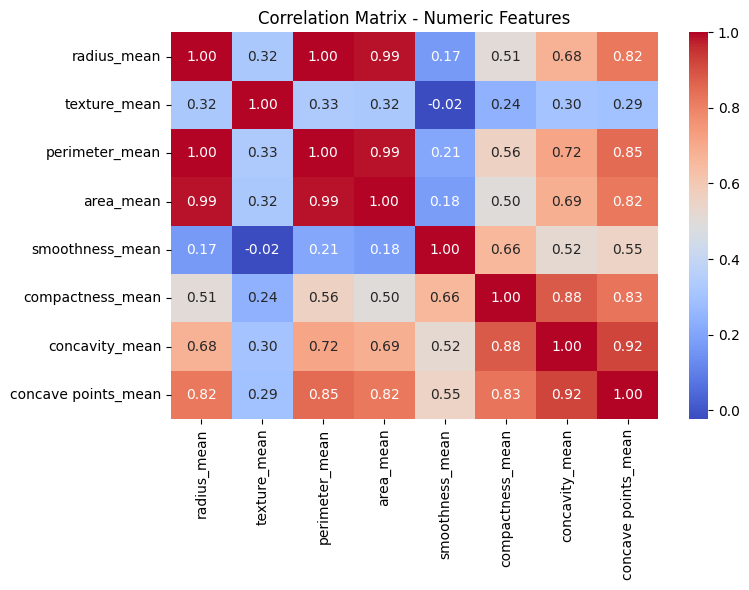

In [8]:
corr_matrix = data[["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean", "concave points_mean"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

In [9]:
# Classes distribution
print(data['diagnosis'].value_counts(normalize=True))

B    0.627417
M    0.372583
Name: diagnosis, dtype: float64


In [10]:
# Data Types
print(data.dtypes)

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [11]:
print("\nInfo")
data.info()


Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se        

# **3. Prepare 2D Data for Visualization**

In [12]:
# Select 2 continuous features for scatter plot + decision boundaries
X = data[['radius_mean','texture_mean']]
y = data['diagnosis']

print("X shape (samples, 2 features):", X.shape)
print("\nFeatures selected:")
print("- Mean radius: Average tumor radius")
print("- Mean texture: Cell texture variation")

X shape (samples, 2 features): (569, 2)

Features selected:
- Mean radius: Average tumor radius
- Mean texture: Cell texture variation


In [13]:
print("\nX sample:\n")
X.head()


X sample:



,radius_mean,texture_mean
0,17.99,10.38
1,20.57,17.77
2,19.69,21.25
3,11.42,20.38
4,20.29,14.34


# **4. Decision Boundary Plot**

In [14]:
def plot_decision_boundary(X, y, k, preprocess=True, title_suffix=""):
    X_num = X.values
    
    # Encoding only categorical data
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    
    # Scale all data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_num)
    
    # KNN model
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_scaled, y)
    
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape).astype(float) 
    
    plt.figure(figsize=(8, 4))
    # Con opción 1:
    cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA"])
    cmap_bold = ListedColormap(["darkred", "darkgreen"])

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, 
                         edgecolor="k", s=50, cmap=cmap_bold)
    plt.xlabel("Mean Radius (scaled)")
    plt.ylabel("Mean Texture (scaled)")
    plt.title(f"KNN Breast Cancer (k={k}) {title_suffix}")
    plt.legend(*scatter.legend_elements(), title="Diagnosis")
    plt.show()


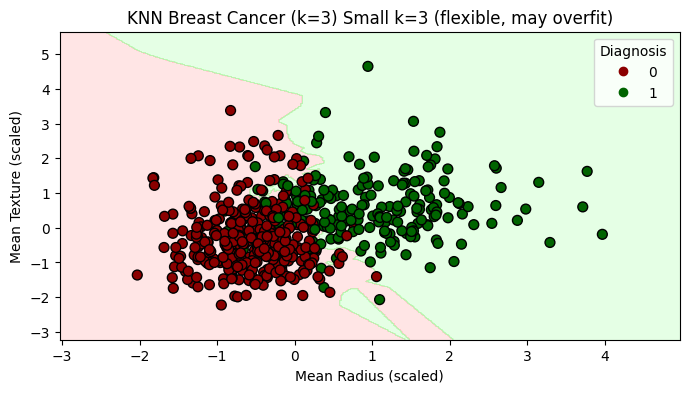

In [15]:
# Small k: Very flexible, follows data noise
plot_decision_boundary(X, y, 
                       k=3, 
                       title_suffix="Small k=3 (flexible, may overfit)")

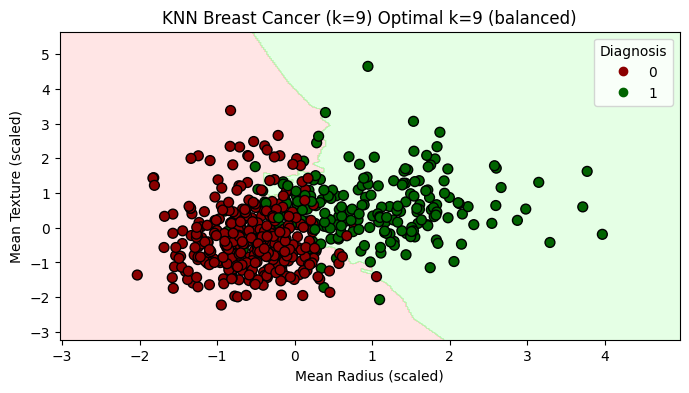

In [16]:
# Medium k: Best balance
plot_decision_boundary(X, y, 
                       k=9, 
                       title_suffix="Optimal k=9 (balanced)")


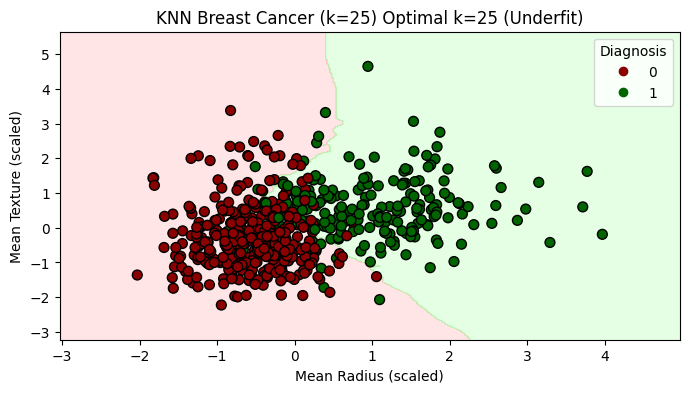

In [17]:
# Large k: May underfit
plot_decision_boundary(X, y, 
                       k=25, 
                       title_suffix="Optimal k=25 (Underfit)")

# **5.  KNN Model Design**

In [18]:
X_train, X_test, y_train_str, y_test_str = train_test_split(X, y, test_size=0.2, random_state=STUDENT_ID)
le = LabelEncoder()
y_train = le.fit_transform(y_train_str)  # 0=M, 1=B
y_test = le.transform(y_test_str)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **6. Evaluation Metrics**

In [19]:
def simple_knn_eval(X_train_scaled, y_train, X_test_scaled, y_test, k=3):
    # Libraries needed for this function    
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
    import pandas as pd
    
    # Train KNN classifier with Euclidean distance
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train_scaled, y_train)
    
    # Predictions and probabilities
    y_pred = knn.predict(X_test_scaled)
    y_proba = knn.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    # Summary results DataFrame
    results = pd.DataFrame({"k": [k], "Accuracy": [round(acc, 3)], "AUC": [round(auc, 3)]})
    
    # Detailed classification report as DataFrame
    report_dataframe = pd.DataFrame(
        classification_report(y_test, y_pred, 
                            target_names=["Malignant (0)", "Benign (1)"], 
                            output_dict=True)
    ).round(3)
    
    # Results displayed
    print("Summary:\n", results)
    print("\nk_report:\n", report_dataframe)
    
    return results, {f'k{k}_report': report_dataframe}

# **7. Confusion Matrix & ROC Curve**

In [ ]:
def plot_confusion_roc(X_train_scaled, y_train, X_test_scaled, y_test, k_best, summary_df, model_name="KNN"):
    # Libraries needed for this function
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
    
     # Refit the model with the specific k value on training data
    knn = KNeighborsClassifier(n_neighbors=k_best, metric="euclidean")
    knn.fit(X_train_scaled, y_train)
    # Prediction and probability of a class
    y_pred_fresh = knn.predict(X_test_scaled)
    y_proba_fresh = knn.predict_proba(X_test_scaled)[:,1]
    
    # Subplots for confusion matrix (left) and ROC curve (right)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_fresh)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Malignant (0)', 'Benign (1)'],
                yticklabels=['Malignant (0)', 'Benign (1)'])
    acc = summary_df[summary_df.k == k_best].Accuracy.iloc[0]
    auc_fresh = roc_auc_score(y_test, y_proba_fresh)  # AUC real
    ax1.set_title(f'{model_name} k={k_best}\nConfusion Matrix (Acc={acc:.3f})')
    
    # ROC Curve with fresh probabilities
    fpr, tpr, _ = roc_curve(y_test, y_proba_fresh)
    ax2.plot(fpr, tpr, linewidth=2.5, color='darkblue', 
             label=f'ROC k={k_best} (AUC={auc_fresh:.3f})')
    ax2.plot([0, 1], [0, 1], 'k--', label='Random') # Diagonal reference line
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.legend()
    ax2.grid(True, alpha=0.3) # Light grid for better readability
    
    # Main title and layout adjustment
    plt.suptitle(f'{model_name} Evaluation k={k_best}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return fig


# **8. Final Results and Comparison**

Summary:
    k  Accuracy    AUC
0  3     0.895  0.953

k_report:
            Malignant (0)  Benign (1)  accuracy  macro avg  weighted avg
precision          0.915        0.86     0.895      0.888         0.895
recall             0.915        0.86     0.895      0.888         0.895
f1-score           0.915        0.86     0.895      0.888         0.895
support           71.000       43.00     0.895    114.000       114.000


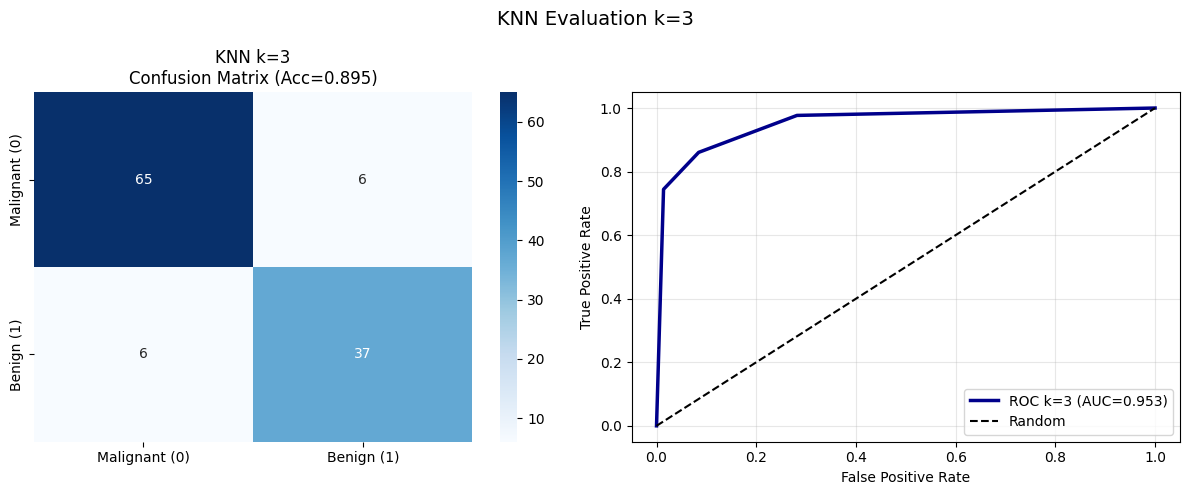

In [21]:
knumber = 3

results, reports = simple_knn_eval(X_train_scaled, y_train, 
                                   X_test_scaled, y_test, 
                                   k=knumber)

fig = plot_confusion_roc(X_train_scaled, y_train, 
                         X_test_scaled, y_test, 
                         knumber, results)

Summary:
    k  Accuracy    AUC
0  9      0.93  0.965

k_report:
            Malignant (0)  Benign (1)  accuracy  macro avg  weighted avg
precision          0.944       0.907      0.93      0.925          0.93
recall             0.944       0.907      0.93      0.925          0.93
f1-score           0.944       0.907      0.93      0.925          0.93
support           71.000      43.000      0.93    114.000        114.00


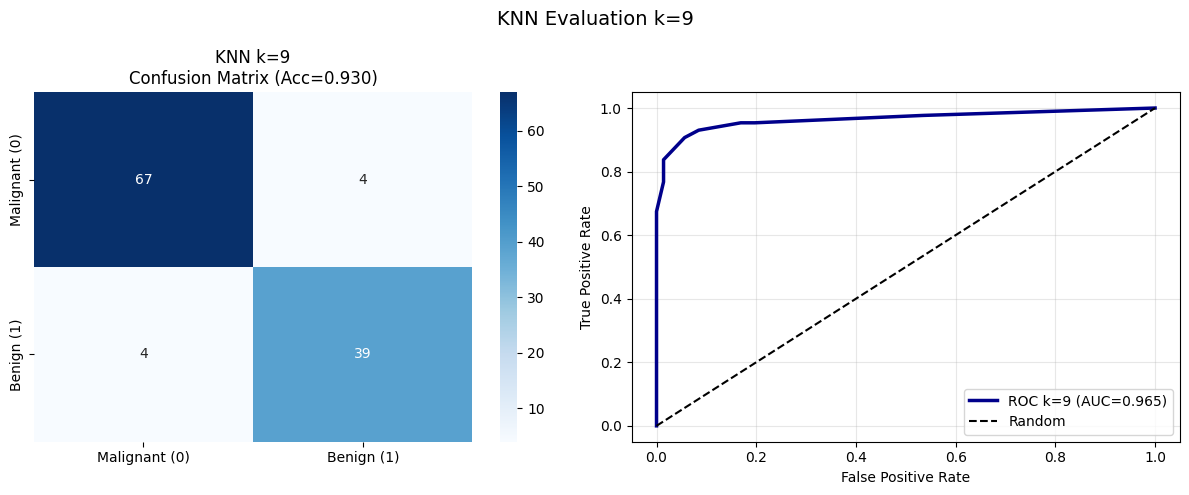

In [22]:
knumber = 9

results, reports = simple_knn_eval(X_train_scaled, y_train, 
                                   X_test_scaled, y_test, 
                                   k=knumber)

fig = plot_confusion_roc(X_train_scaled, y_train, 
                         X_test_scaled, y_test, 
                         knumber, results)

Summary:
     k  Accuracy    AUC
0  25     0.904  0.968

k_report:
            Malignant (0)  Benign (1)  accuracy  macro avg  weighted avg
precision          0.929       0.864     0.904      0.896         0.904
recall             0.915       0.884     0.904      0.900         0.904
f1-score           0.922       0.874     0.904      0.898         0.904
support           71.000      43.000     0.904    114.000       114.000


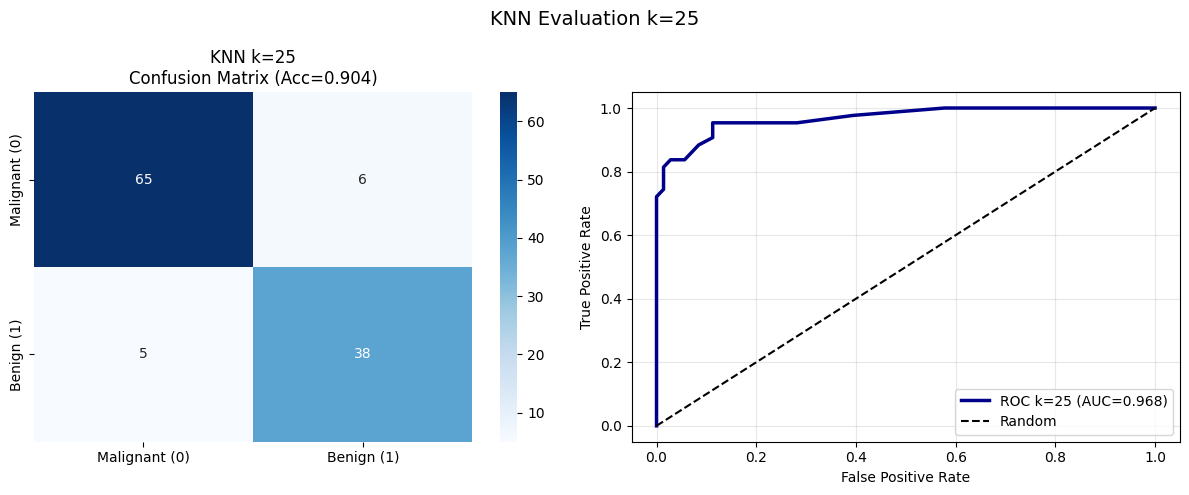

In [23]:
knumber = 25

results, reports = simple_knn_eval(X_train_scaled, y_train, 
                                   X_test_scaled, y_test, 
                                   k=knumber)

fig = plot_confusion_roc(X_train_scaled, y_train, 
                         X_test_scaled, y_test, 
                         knumber, results)